For gini with split of 0.25 we got 97.3%  
For gini with split of 0.20 we got 100.0%  
For gini with split of 0.30 we got 97.7% 

For entropy with split of 0.25 we got 97.3%  
For entropy with split of 0.20 we got 100.0%  
For entropy with split of 0.30 we got 97.7%

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [106]:
dataset = pd.read_csv('../DATA/Iris.csv')

x = dataset.iloc[ : , 1:5].values
y = dataset.iloc[: , -1].values

In [107]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x , y , test_size=0.30 , random_state=0)

In [108]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [109]:
from sklearn.tree import DecisionTreeClassifier
classifer = DecisionTreeClassifier( criterion = 'entropy', random_state=0 )
#classifer = DecisionTreeClassifier( criterion = 'gini', random_state=0 )
classifer.fit(x_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [110]:
y_pred = classifer.predict(x_test)
y_pred

array([2, 0, 1, 2, 1, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 1, 2, 0, 0, 2, 1, 2, 1,
       1])

In [111]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[17,  0,  1],
       [ 0, 16,  0],
       [ 0,  0, 11]])

In [112]:
from sklearn import metrics
predection = metrics.accuracy_score(y_pred, y_test)
print("Accuracy:", predection *100 , "%")

Accuracy: 97.77777777777777 %


In [113]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00        16
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [114]:
new_individual = np.array([[5.1,3.7,1.7,0.3]])
new_individual_scaled = sc.transform(new_individual)
new_predection = classifer.predict(new_individual_scaled)

if new_predection[0] == 1:
    print("it is species")
    
else:
    print("it is not species")    


it is species


[Text(0.4, 0.9, 'x[3] <= -0.613\nentropy = 1.58\nsamples = 105\nvalue = [32, 34, 39]'),
 Text(0.3, 0.7, 'entropy = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[2] <= 0.624\nentropy = 0.993\nsamples = 71\nvalue = [32, 0, 39]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[3] <= 0.544\nentropy = 0.431\nsamples = 34\nvalue = [31, 0, 3]'),
 Text(0.1, 0.3, 'entropy = 0.0\nsamples = 30\nvalue = [30, 0, 0]'),
 Text(0.3, 0.3, 'x[1] <= 0.126\nentropy = 0.811\nsamples = 4\nvalue = [1, 0, 3]'),
 Text(0.2, 0.1, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.4, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.8, 0.5, 'x[3] <= 0.673\nentropy = 0.179\nsamples = 37\nvalue = [1, 0, 36]'),
 Text(0.7, 0.3, 'x[3] <= 0.544\nentropy = 0.811\nsamples = 4\nvalue = [1, 0, 3]'),
 Text(0.6, 0.1, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.9, 0.3, 'entropy = 0.0\ns

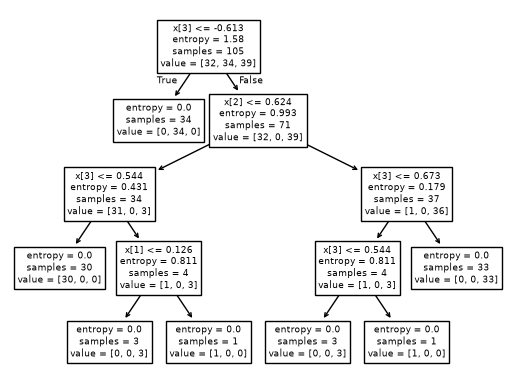

In [115]:
from sklearn import tree
tree.plot_tree(classifer)